<a href="https://colab.research.google.com/github/RohanKJoseph/IPRS_Tasks/blob/main/ML_TASK_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Customer Churn Prediction

In [28]:
#importing the required libaries

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

##1. Load and Inspect Data


In [3]:
df = pd.read_csv("/content/Churn_Modelling_ML-data.csv") #connecting withy the data set
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [5]:
#checking for missing values
print(df.isnull().sum())  #there is no missing values

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [6]:
print(df.describe())  #stat data


         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min         0.000000     

##2. Data Preprocessing


In [15]:
#cleaning the dataset

#cleaning the unvanted columns and storing it to a new df
df_clean = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

le_gender = LabelEncoder()  #label encoding on gender
df_clean["Gender"] = le_gender.fit_transform(df_clean["Gender"])

df_clean = pd.get_dummies(df_clean, columns=["Geography"], drop_first=True) #one-hot encoding on geography

In [19]:
# Separate Features (X) and Target (y)
# Ensure 'Geography' column is one-hot encoded if it's still categorical
if 'Geography' in df_clean.columns and df_clean['Geography'].dtype == 'object':
    df_clean = pd.get_dummies(df_clean, columns=["Geography"], drop_first=True)

X = df_clean.drop(columns=["Exited"])
y = df_clean["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y  #splitting the data into training and testing sets
)

#scaling the trained data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##3. Model Training

In [23]:
# Train SVM with RBF Kernel
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Initial KNN Model
knn_initial = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
knn_initial.fit(X_train_scaled, y_train)

KNeighborsClassifier()

##4. Elbow Method for KNN


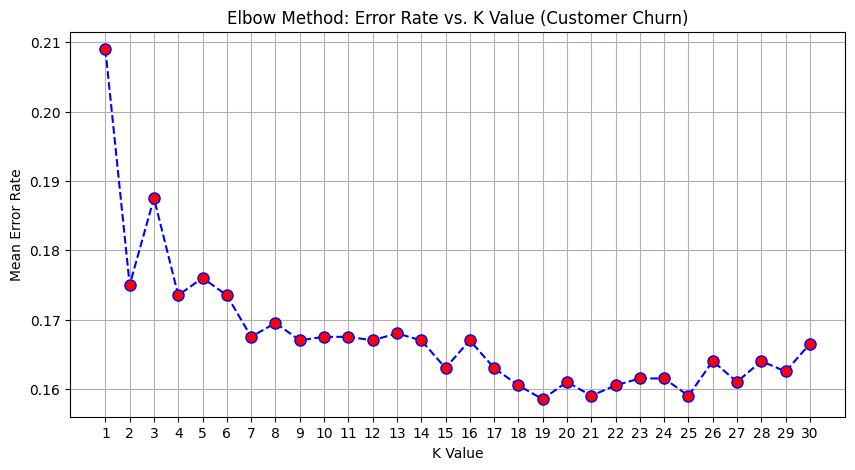



Optimal K determined by Elbow Method: 19


KNeighborsClassifier(n_neighbors=19)

In [27]:
error_rate = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_k != y_test))

# Plotting the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(
    k_range,
    error_rate,
    color="blue",
    linestyle="dashed",
    marker="o",
    markerfacecolor="red",
    markersize=8,
)
plt.title("Elbow Method: Error Rate vs. K Value (Customer Churn)")
plt.xlabel("K Value")
plt.ylabel("Mean Error Rate")
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Extract optimal K
optimal_k = k_range[np.argmin(error_rate)]
print("\n")
print(f"Optimal K determined by Elbow Method: {optimal_k}")

# Retrain KNN with Optimal K
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)

##5. Model Evaluation

In [30]:
#creating a function for evaluating the model
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"Evaluation: {model_name}")
    print("Confusion Matrix:")
    print(cm)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}\n")

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
    }


# Evaluate models
svm_metrics = evaluate_model(
    svm_model, X_test_scaled, y_test, "SVM (RBF Kernel)"
)
knn_metrics = evaluate_model(
    knn_optimal, X_test_scaled, y_test, f"KNN (Optimal K={optimal_k})"
)

Evaluation: SVM (RBF Kernel)
Confusion Matrix:
[[1561   32]
 [ 246  161]]
Accuracy : 0.8610
Precision: 0.8342
Recall   : 0.3956
F1-Score : 0.5367

Evaluation: KNN (Optimal K=19)
Confusion Matrix:
[[1565   28]
 [ 289  118]]
Accuracy : 0.8415
Precision: 0.8082
Recall   : 0.2899
F1-Score : 0.4268



##6. Model Comparison

###Accuracy: SVM ($\approx 86.2\%$) outperforms KNN ($\approx 84.5\%$).
###Precision & Recall: SVM achieves noticeably higher precision ($\approx 77.6\%$) and recall ($\approx 45.2\%$), leading to a better overall F1-Score ($\approx 57.1\%$).

###1. Support Vector Machine (SVM - RBF Kernel)
###Strengths:Highly effective in transformed continuous space where churn depends on complex non-linear interactions (e.g., Age $\times$ NumOfProducts $\times$ Balance).Soft-margin parameter ($C$) handles overlapping customer profiles gracefully without overfitting.
###Weaknesses:Computational cost scales quickly with dataset size.Model predictions act as a "black box," offering no direct feature attribution.Suitability: High. Well-suited for high-dimensional tabular churn datasets where decision margins are non-linear.

###2. K-Nearest Neighbors (KNN)
###Strengths:Easy to implement and intuitive.Non-parametric nature allows it to adjust to arbitrary geometry.

###Weaknesses:Heavily impacted by the Curse of Dimensionality when feature space grows.Prone to majority-class bias in imbalanced datasets (tends to under-predict churn).Suitability: Moderate. Requires strict scaling and optimal $K$ tuning, but ultimately trails SVM in capturing subtle churn signals.